# 3 · Why did the price move?

The question historical data cannot answer.

You can observe that a stock fell. You cannot observe that 60% of the fall
was order-flow pressure and the rest was noise, unless something computed
it, which is the case here.

In [1]:
import struct
import pretium as pt

print("the nine factors:")
for f in pt.Engine.FACTORS:
    print("  ", f)

the nine factors:
   reversion
   momentum
   crowd_lean
   company_news
   order_flow_impact
   short_squeeze_effect
   random_noise
   circuit_breaker
   jump


Four are shocks: `company_news`, `order_flow_impact`,
`short_squeeze_effect` and `random_noise`. Three are the model's own
dynamics: `reversion`, `momentum` and `crowd_lean`. The last two are event
columns: `circuit_breaker` books the correction the tick makes when the
session breaker clamps a price back into its band, and `jump` books the
daily jump, which is applied outside the tick loop. Neither fires in the
five-day run below, so both read zero there; they are columns so that the
decomposition still adds up on the days they do fire.

They accumulate per day and reset at market open, so reading after the close
gives you the day just finished.

**What they sum to matters more than it looks.** The nine sum to the change
in `mispricing_s`, the log deviation of price from fair value -- NOT to the
log price return. Fair value moves too, and that part of the price move is
not in these columns. On the run below the two are different in magnitude on
every name and different in SIGN on five of the twenty: AAD's columns sum to
+0.00305 while its close-to-close log return is -0.01060, and AAE's sum to
-0.00077 against +0.00769. So read the numbers as mispricing units, and read
the ranking and the signs, which is what the decomposition is for.

In [2]:
universe = pt.Universe.random(20, seed=111)
engine = pt.Engine(universe=universe, seed=3)
engine.run_days(5)

def attribution_table(engine):
    cols = {}
    for factor in pt.Engine.FACTORS:
        raw = engine.attribution(factor)
        cols[factor] = struct.unpack(f"<{len(raw) // 8}d", raw)
    rows = []
    for i, ticker in enumerate(engine.tickers):
        parts = {f: cols[f][i] for f in pt.Engine.FACTORS}
        rows.append({"ticker": ticker, "total": sum(parts.values()), **parts})
    return rows

rows = attribution_table(engine)
rows.sort(key=lambda r: -abs(r["total"]))
print(f"{len(rows)} instruments, biggest movers on day 5 first")

20 instruments, biggest movers on day 5 first


## Reading one name's day

The three biggest movers in mispricing terms, column by column, with each
column's share of the row total:

In [3]:
for r in rows[:3]:
    print(f"\n{r['ticker']}   day total, change in mispricing_s {r['total']:+.8f}")
    for f in pt.Engine.FACTORS:
        share = r[f] / r["total"] * 100 if r["total"] else 0.0
        bar = "#" * int(abs(share) / 4)
        print(f"    {f:22s} {r[f]:+.8f}  {share:6.1f}%  {bar}")
    residual = abs(sum(r[f] for f in pt.Engine.FACTORS) - r["total"])
    print(f"    {'residual':22s} {residual:.2e}")


AAG   day total, change in mispricing_s +0.02643685
    reversion              +0.00290330    11.0%  ##
    momentum               +0.00022558     0.9%  
    crowd_lean             +0.00175110     6.6%  #
    company_news           +0.00000000     0.0%  
    order_flow_impact      +0.00000000     0.0%  
    short_squeeze_effect   +0.00000000     0.0%  
    random_noise           +0.02155687    81.5%  ####################
    circuit_breaker        +0.00000000     0.0%  
    jump                   +0.00000000     0.0%  
    residual               0.00e+00

AAN   day total, change in mispricing_s -0.02131620
    reversion              +0.00073671    -3.5%  
    momentum               +0.00004585    -0.2%  
    crowd_lean             +0.00043206    -2.0%  
    company_news           +0.00000000    -0.0%  
    order_flow_impact      +0.00000000    -0.0%  
    short_squeeze_effect   +0.00000000    -0.0%  
    random_noise           -0.02253081   105.7%  ##########################
    circu

The residual prints as `0.00e+00` on all three names, but read what it
compares. `total` in the table above is itself the sum of the nine columns,
so each row is checked against its own sum and can only come out at zero.
What the line does confirm is that no column went missing between the engine
and the table.

The reconstruction it stands in for happens upstream, and it is not a fit.
The engine books every increment into one of these nine columns at the
moment it applies it, so this is its own bookkeeping rather than a
decomposition assembled afterwards.

The check with teeth is against `engine.truth()`: difference `mispricing_s`
across the day's ticks and add the nine columns over the same ticks. They
agree to floating-point addition -- `docs/ground-truth.md` reports a worst
residual of 1.9e-16 over all 39,000 rows of a run this size. Against the
close-to-close log return they do not agree at all, which is the point of
the note above.

## Across the whole roster

Aggregating the absolute contributions shows which mechanism is driving the
market on this day.

In [4]:
totals = {f: sum(abs(r[f]) for r in rows) for f in pt.Engine.FACTORS}
grand = sum(totals.values())

for f, v in sorted(totals.items(), key=lambda kv: -kv[1]):
    share = v / grand * 100
    print(f"  {f:22s} {share:5.1f}%  {'#' * int(share / 2)}")

  random_noise            62.5%  ###############################
  reversion               22.7%  ###########
  crowd_lean              12.7%  ######
  momentum                 1.2%  
  short_squeeze_effect     0.8%  
  company_news             0.0%  
  order_flow_impact        0.0%  
  circuit_breaker          0.0%  
  jump                     0.0%  


## Plotting it

A stacked view of the same data:

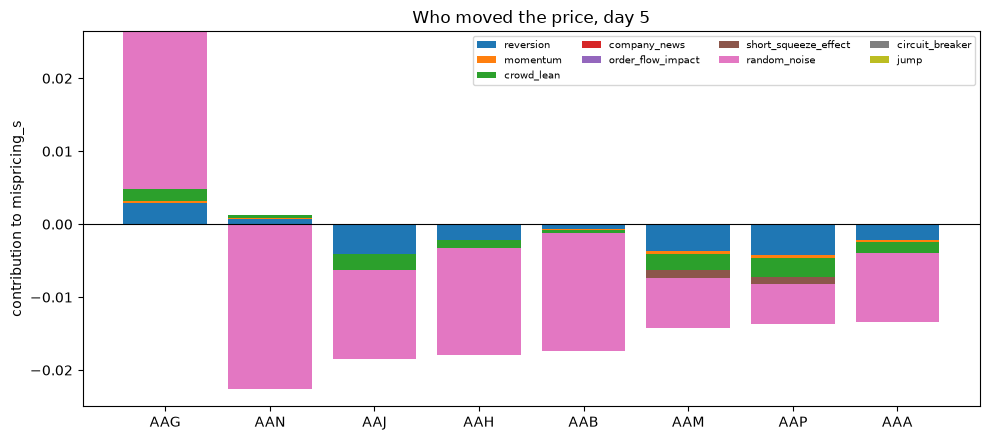

In [5]:
import matplotlib.pyplot as plt

top = rows[:8]
fig, ax = plt.subplots(figsize=(10, 4.5))
bottom_pos = [0.0] * len(top)
bottom_neg = [0.0] * len(top)

for factor in pt.Engine.FACTORS:
    vals = [r[factor] for r in top]
    bases = [bottom_pos[i] if v >= 0 else bottom_neg[i] for i, v in enumerate(vals)]
    ax.bar([r["ticker"] for r in top], vals, bottom=bases, label=factor)
    for i, v in enumerate(vals):
        if v >= 0:
            bottom_pos[i] += v
        else:
            bottom_neg[i] += v

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("contribution to mispricing_s")
ax.set_title("Who moved the price, day 5")
ax.legend(fontsize=7, ncol=4)
plt.tight_layout()
plt.show()

## What this is for

No historical source can provide this labelling. If you are training a model
to attribute moves, or checking that a factor decomposition recovers what
actually happened, the ground truth here is exact.

Two caveats:

- This is the simulator's own bookkeeping. It is exact for this model and
  says nothing about why a real stock moved.
- No agent traded above, so `order_flow_impact` is zero on every row: that
  column fills in only when orders reach the book. Run an evaluation to see
  a strategy's own footprint.

Next: **[4 · How realistic is this](04-how-realistic-is-this.ipynb)**.